In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
import polars as pl
import glob

plt.style.use('seaborn-v0_8')
pl.Config.set_tbl_cols(-1)

# Heuristic thresholds for user EDA
MAX_CAT_CARDINALITY = 50
MAX_CAT_MISSING_RATE = 0.6
MAX_NUM_MISSING_RATE = 0.3

# Global config
TOP_K = 15
RANDOM_STATE = 42
SAMPLE_N = 100_000


In [17]:
# Dùng scan_parquet để lazy load tất cả file phù hợp pattern
item_df = pl.scan_parquet('sales_pers.item_chunk_0.parquet')
user_df = pl.scan_parquet('sales_pers.user_chunk_*.parquet')
purchase_df = pl.scan_parquet('sales_pers.purchase_history_daily_chunk_*.parquet')

#Preview 100 dòng đầu tiên 
preview = purchase_df.head(100).collect()
print(preview)

shape: (100, 16)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬────────┐
│ tim ┆ use ┆ ite ┆ eve ┆ eve ┆ pri ┆ dat ┆ qua ┆ cus ┆ cre ┆ upd ┆ cha ┆ pay ┆ loc ┆ dis ┆ is_del │
│ est ┆ r_i ┆ m_i ┆ nt_ ┆ nt_ ┆ ce  ┆ e_k ┆ nti ┆ tom ┆ ate ┆ ate ┆ nne ┆ men ┆ ati ┆ cou ┆ eted   │
│ amp ┆ d   ┆ d   ┆ typ ┆ val ┆ --- ┆ ey  ┆ ty  ┆ er_ ┆ d_d ┆ d_d ┆ l   ┆ t   ┆ on  ┆ nt  ┆ ---    │
│ --- ┆ --- ┆ --- ┆ e   ┆ ue  ┆ dec ┆ --- ┆ --- ┆ id  ┆ ate ┆ ate ┆ --- ┆ --- ┆ --- ┆ --- ┆ bool   │
│ i64 ┆ str ┆ str ┆ --- ┆ --- ┆ ima ┆ i32 ┆ i32 ┆ --- ┆ --- ┆ --- ┆ str ┆ str ┆ i32 ┆ dec ┆        │
│     ┆     ┆     ┆ str ┆ dec ┆ l[3 ┆     ┆     ┆ i32 ┆ dat ┆ dat ┆     ┆     ┆     ┆ ima ┆        │
│     ┆     ┆     ┆     ┆ ima ┆ 8,4 ┆     ┆     ┆     ┆ eti ┆ eti ┆     ┆     ┆     ┆ l[3 ┆        │
│     ┆     ┆     ┆     ┆ l[3 ┆ ]   ┆     ┆     ┆     ┆ me[ ┆ me[ ┆     ┆     ┆     ┆ 8,4 ┆        │
│     ┆     ┆     ┆     ┆ 8,4 ┆     ┆     ┆     ┆     ┆ μs] ┆ μs] ┆     ┆ 

In [18]:
# Hàm đọc dữ liệu từ các file cùng dạng
def get_parquet_shape(pattern: str):
    """Đếm tổng số dòng và số cột của tất cả file khớp pattern .parquet."""
    files = glob.glob(pattern)
    total_rows = 0
    total_columns = None

    for file in files:
        meta = pq.ParquetFile(file).metadata
        total_rows += meta.num_rows
        total_columns = meta.num_columns  # tất cả file cùng schema

    return total_rows, total_columns

# --- Thực thi cho 3 dataset ---
datasets = {
    "Items": "sales_pers.item_chunk_*.parquet",
    "Users": "sales_pers.user_chunk_*.parquet",
    "Purchases": "sales_pers.purchase_history_daily_chunk_*.parquet"
}

print("\nTHỐNG KÊ DỮ LIỆU PARQUET")
for name, pattern in datasets.items():
    rows, cols = get_parquet_shape(pattern)
    print(f"{name:<10}: {rows:,} rows × {cols} columns")



THỐNG KÊ DỮ LIỆU PARQUET
Items     : 27,332 rows × 34 columns
Users     : 4,573,964 rows × 18 columns
Purchases : 35,729,825 rows × 16 columns


In [19]:
# Các cột của dữ liệu
print("\nItems columns:")
print(item_df.columns)

print("\nUsers columns:")
print(user_df.columns)

print("\nPurchases columns:")
print(purchase_df.columns)


Items columns:
['p_id', 'item_id', 'price', 'category_l1_id', 'category_l1', 'category_l2_id', 'category_l2', 'category_l3_id', 'category_l3', 'category_id', 'category', 'description', 'brand', 'manufacturer', 'creation_timestamp', 'is_deleted', 'created_date', 'updated_date', 'sync_status_id', 'last_sync_date', 'sync_error_message', 'image_url', 'gender_target', 'age_group', 'item_type', 'gp', 'weight', 'color', 'size', 'origin', 'volume', 'material', 'sale_status', 'description_new']

Users columns:
['customer_id', 'gender', 'location', 'province', 'membership', 'timestamp', 'created_date', 'updated_date', 'sync_status_id', 'last_sync_date', 'sync_error_message', 'region', 'location_name', 'install_app', 'install_date', 'district', 'user_id', 'is_deleted']

Purchases columns:
['timestamp', 'user_id', 'item_id', 'event_type', 'event_value', 'price', 'date_key', 'quantity', 'customer_id', 'created_date', 'updated_date', 'channel', 'payment', 'location', 'discount', 'is_deleted']


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18916\2411707227.py:3: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  print(item_df.columns)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18916\2411707227.py:6: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  print(user_df.columns)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18916\2411707227.py:9: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  print(purchase_df.columns)


In [20]:
print(item_df.head(5).collect())


shape: (5, 34)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ p_i ┆ ite ┆ pri ┆ cat ┆ cat ┆ cat ┆ cat ┆ cat ┆ cat ┆ cat ┆ cat ┆ des ┆ bra ┆ man ┆ cre ┆ is_ ┆ cre ┆ upd ┆ syn ┆ las ┆ syn ┆ ima ┆ gen ┆ age ┆ ite ┆ gp  ┆ wei ┆ col ┆ siz ┆ ori ┆ vol ┆ mat ┆ sal ┆ des │
│ d   ┆ m_i ┆ ce  ┆ ego ┆ ego ┆ ego ┆ ego ┆ ego ┆ ego ┆ ego ┆ ego ┆ cri ┆ nd  ┆ ufa ┆ ati ┆ del ┆ ate ┆ ate ┆ c_s ┆ t_s ┆ c_e ┆ ge_ ┆ der ┆ _gr ┆ m_t ┆ --- ┆ ght ┆ or  ┆ e   ┆ gin ┆ ume ┆ eri ┆ e_s ┆ cri │
│ --- ┆ d   ┆ --- ┆ ry_ ┆ ry_ ┆ ry_ ┆ ry_ ┆ ry_ ┆ ry_ ┆ ry_ ┆ ry  ┆ pti ┆ --- ┆ ctu ┆ on_ ┆ ete ┆ d_d ┆ d_d ┆ tat ┆ ync ┆ rro ┆ url ┆ _ta ┆ oup ┆ ype ┆ dec ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- ┆ al  ┆ tat ┆ pti │
│ i32 ┆ --- ┆ dec ┆ l1_ ┆ l1  ┆ l2_ ┆ l2  ┆ l3_ ┆ l3  ┆ id  ┆ --- ┆ on  ┆ str ┆ rer ┆ tim ┆ d   ┆ ate ┆ ate ┆ us_ ┆ _da ┆ r_m ┆ --- ┆ rge ┆ --- ┆ --- ┆ ima ┆ f32

# Phân tích đơn biến (Item Data)

## Biến định lượng 

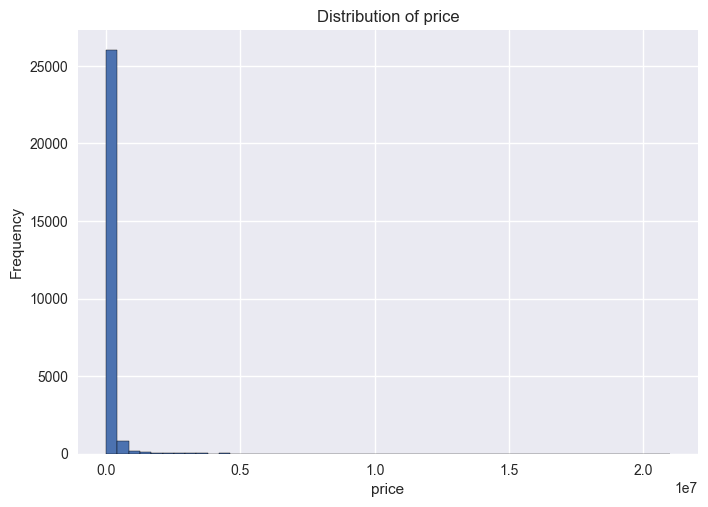

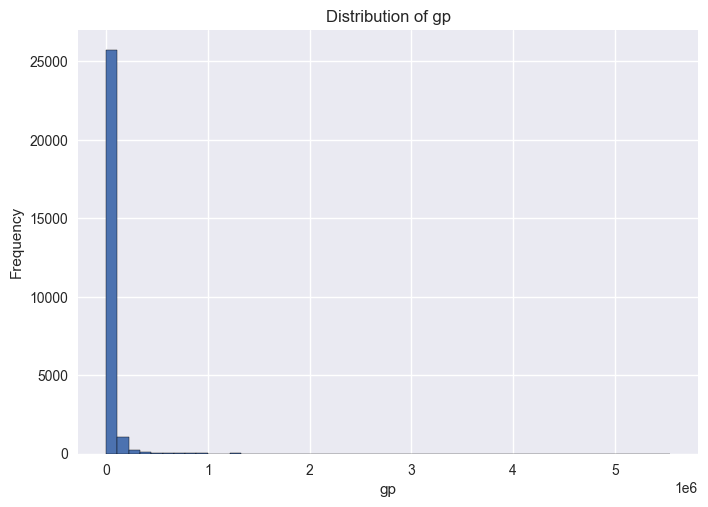

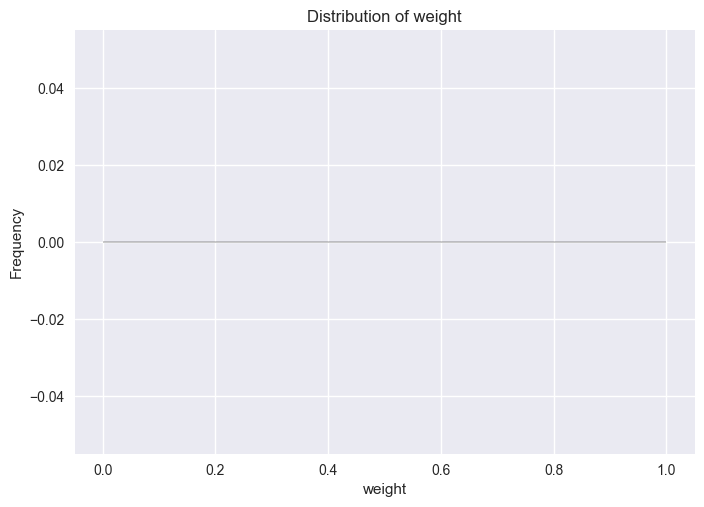

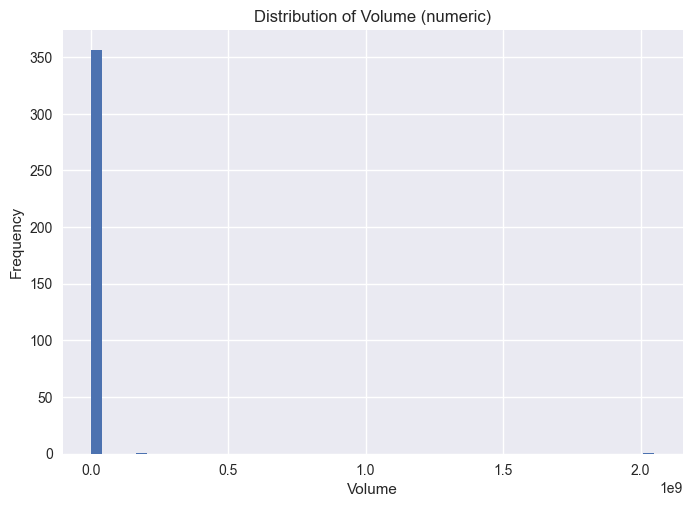

In [27]:
quant_cols = ["price", "gp", "weight"]

for col in quant_cols:
    df = item_df.select(col).collect().to_pandas()
    df[col].hist(bins=50, edgecolor='black')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

cleaned_volume = cleaned_volume.drop_nulls("volume_numeric")

plt.hist(cleaned_volume["volume_numeric"].to_numpy(), bins=50)
plt.title("Distribution of Volume (numeric)")
plt.xlabel("Volume")
plt.ylabel("Frequency")
plt.show()


## Biến định tính

In [34]:
def analyze_categorical(df, col_name, top_n=10):
    # Nếu là LazyFrame → collect
    if isinstance(df, pl.LazyFrame):
        df = df.collect()

    # Đếm tần suất & tính phần trăm
    freq = (
        df
        .group_by(col_name)  # ✅ cú pháp đúng của Polars
        .len()
        .with_columns(
            (pl.col("len") / pl.col("len").sum() * 100).alias("percent")
        )
        .sort("len", descending=True)
        .limit(top_n)
    )

    # Chuyển sang pandas để in và vẽ
    freq_pd = freq.to_pandas()

    # In bảng tần suất
    print(f"\n🔹 Top {top_n} giá trị phổ biến trong '{col_name}':")
    print(freq_pd)

    # Vẽ biểu đồ bar
    plt.figure(figsize=(10, 5))
    plt.bar(freq_pd[col_name], freq_pd["len"], color="orange")
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Top {top_n} '{col_name}' theo tần suất xuất hiện")
    plt.xlabel(col_name)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()



🔹 Top 10 giá trị phổ biến trong 'brand':
                  brand   len    percent
0                 Animo  8149  29.814869
1        Không xác định  5480  20.049759
2  CF (ConCung Fashion)  5426  19.852188
3      Thương hiệu khác   607   2.220840
4              Con Cưng   484   1.770818
5               TOYCITY   300   1.097615
6          ConCung Good   211   0.771989
7                  Nous   140   0.512220
8                Pigeon   120   0.439046
9                Mesuca   114   0.417094


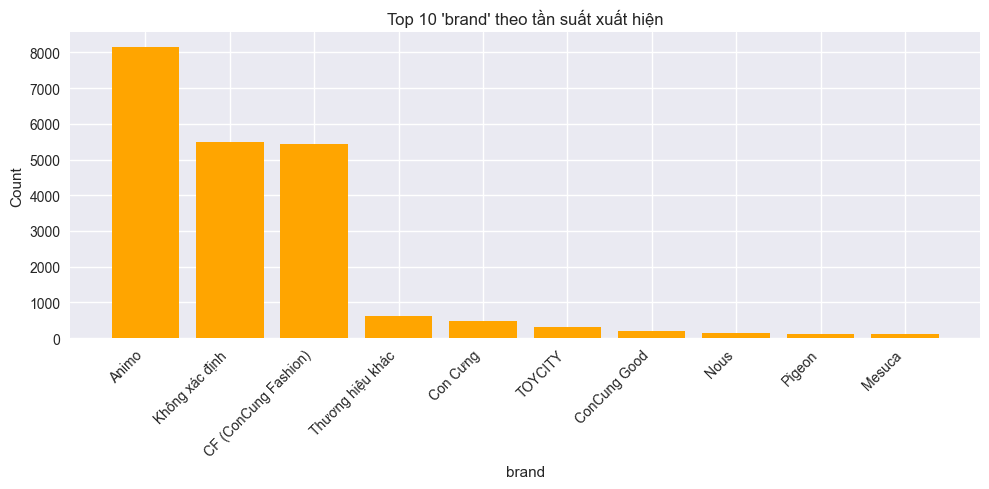


🔹 Top 10 giá trị phổ biến trong 'category_l1':
              category_l1    len    percent
0              Thời trang  15042  55.034392
1                Phụ kiện   3147  11.513976
2          Đồ chơi & Sách   2955  10.811503
3                Babycare   1994   7.295478
4        Thực phẩm cho bé    981   3.589199
5                 Textile    555   2.030587
6  Thực phẩm cho gia đình    470   1.719596
7                      Tã    442   1.617152
8                     Sữa    437   1.598858
9    Hóa mỹ phẩm gia đình    388   1.419581


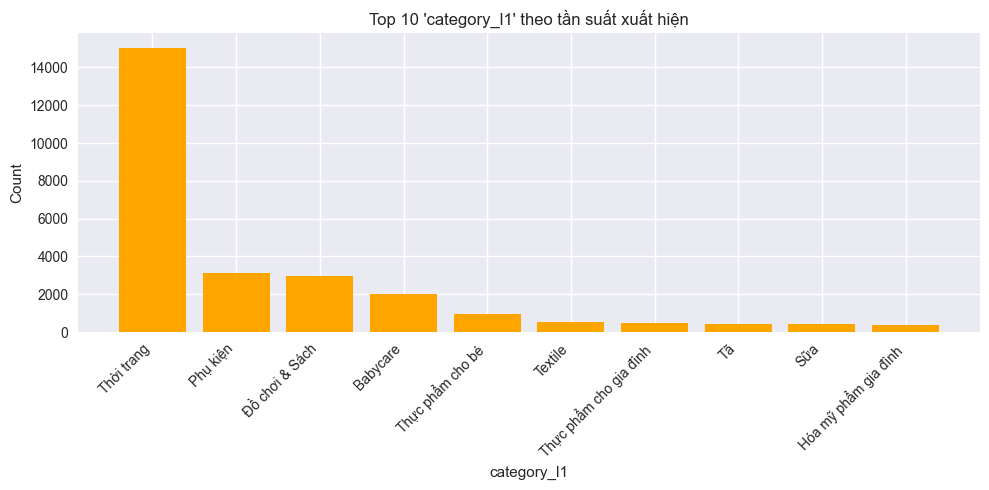


🔹 Top 10 giá trị phổ biến trong 'manufacturer':
                                        manufacturer    len    percent
0                                     Không xác định  25767  94.274111
1                                           Unilever     28   0.102444
2              Mead Johnson Nutrition (Thailand) Ltd     20   0.073174
3  Công ty Cổ Phần Thực Phẩm Dinh Dưỡng Nutifood ...     19   0.069516
4                                           Vinamilk     17   0.062198
5                                     Hayat Việt Nam     12   0.043905
6                  Australia Deloraine Dairy Pty Ltd     11   0.040246
7                                          VitaDairy     11   0.040246
8                                    LONG HAPPY TOYS     11   0.040246
9  CÔNG TY CỔ PHẦN SÀI GÒN FOOD - CHI NHÁNH VĨNH ...     11   0.040246


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18916\1587435706.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


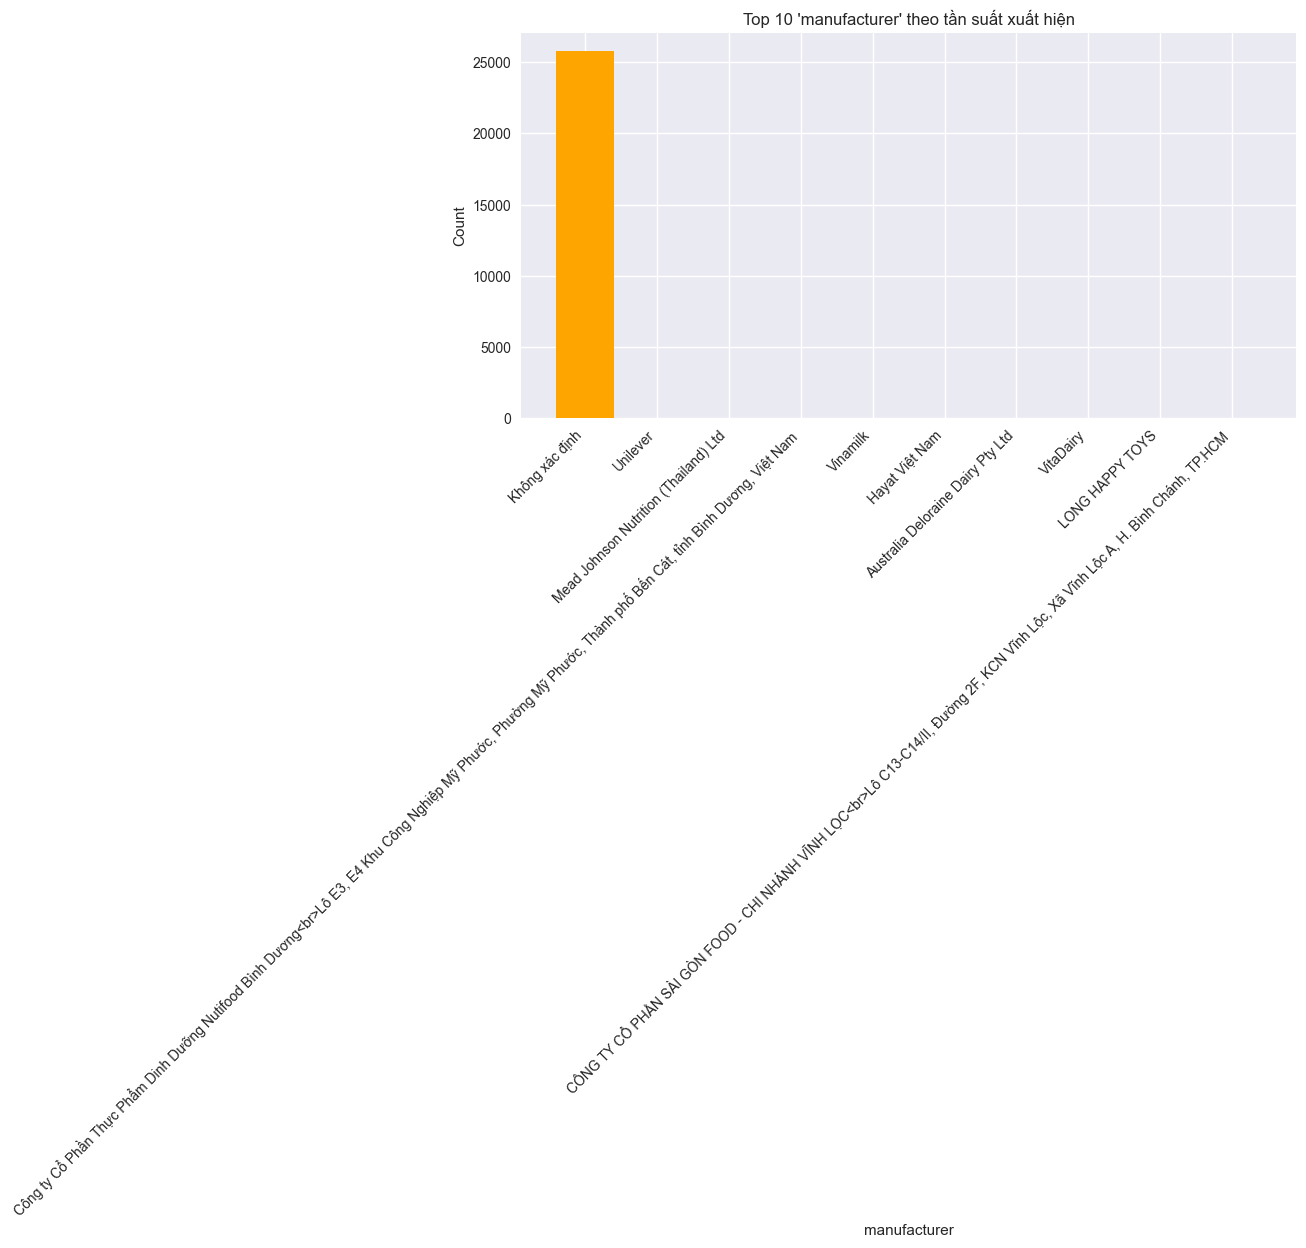


🔹 Top 10 giá trị phổ biến trong 'origin':
               origin    len    percent
0      Không xác định  22627  82.785746
1            Việt Nam   1991   7.284502
2          Trung Quốc    584   2.136690
3            Hàn Quốc    216   0.790282
4  Việt Nam, Việt Nam    190   0.695156
5            Nhật Bản    175   0.640275
6  Nhật Bản, Nhật Bản    171   0.625640
7            Thái Lan    141   0.515879
8                  Úc     61   0.223182
9           Singapore     49   0.179277


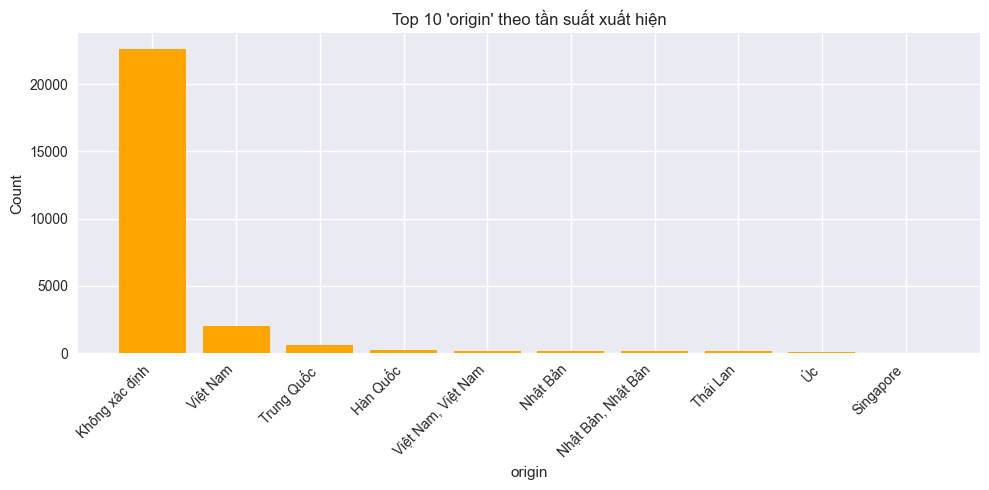


🔹 Top 10 giá trị phổ biến trong 'gender_target':
    gender_target    len    percent
0  Không xác định  18038  65.995902
1          Bé Gái   4108  15.030001
2         Bé Trai   3318  12.139617
3         Sơ sinh   1862   6.812527
4          Unisex      6   0.021952


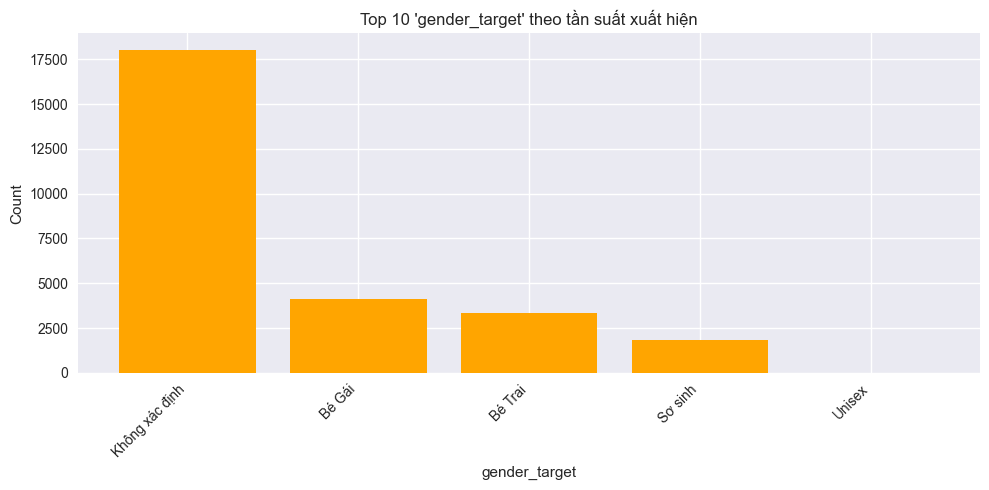


🔹 Top 10 giá trị phổ biến trong 'sale_status':
   sale_status    len    percent
0            0  22762  83.279672
1            1   4570  16.720328


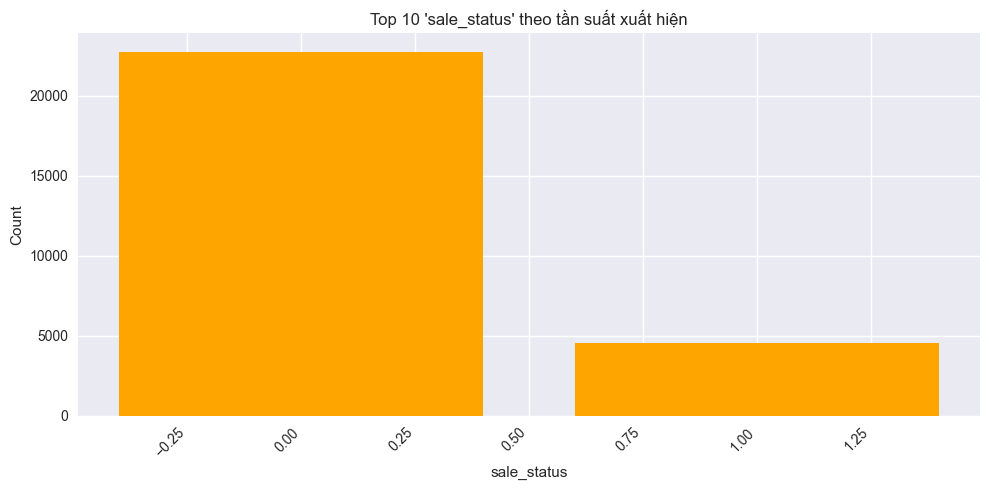


🔹 Top 10 giá trị phổ biến trong 'material':
                                       material    len    percent
0                                Không xác định  24664  90.238548
1                                   100% cotton    454   1.661057
2                             Cotton, Polyester    227   0.830528
3                                      Nhựa ABS    142   0.519538
4                                       Nhựa PP    107   0.391483
5                                   100% Cotton     60   0.219523
6                           100% cotton, 150gsm     42   0.153666
7                         95% modal, 5% spandex     37   0.135372
8  Vải nhân tạo, Bông nhân tạo (100% Polyester)     28   0.102444
9                                      Nhựa EVA     28   0.102444


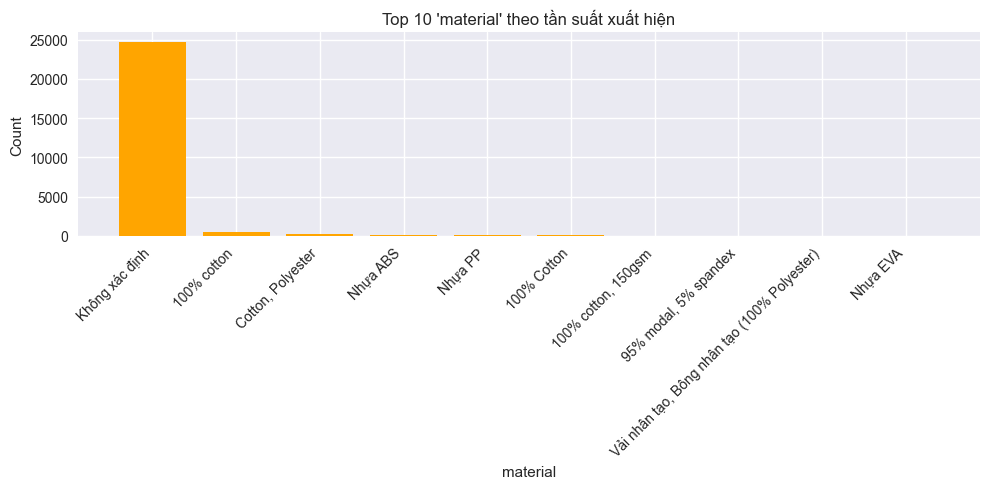


🔹 Top 10 giá trị phổ biến trong 'color':
            color    len    percent
0  Không xác định  26608  97.351090
1            Xanh    165   0.603688
2            Hồng    164   0.600029
3           Trắng     81   0.296356
4            Vàng     48   0.175618
5       Nhiều màu     40   0.146349
6              Đỏ     34   0.124396
7             Xám     31   0.113420
8      Xanh dương     21   0.076833
9             Cam     14   0.051222


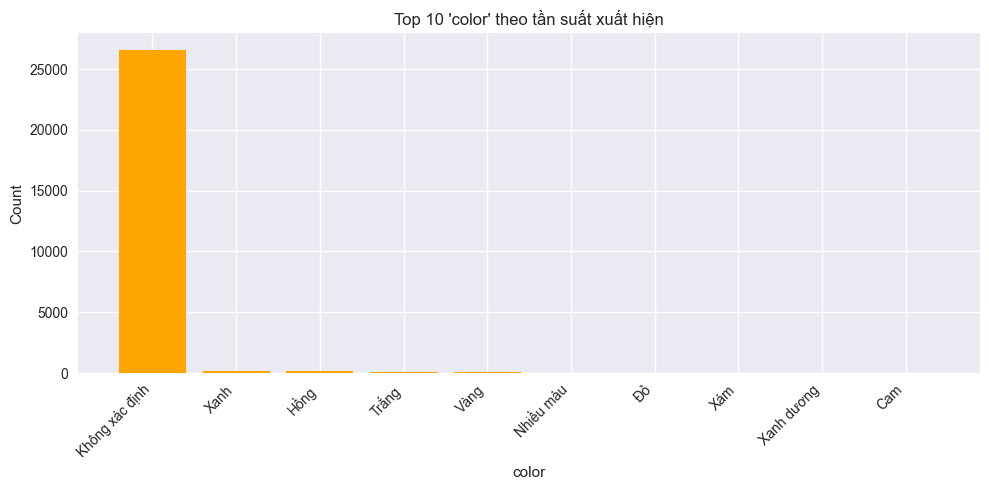


🔹 Top 10 giá trị phổ biến trong 'size':
             size    len    percent
0  Không xác định  25108  91.863018
1            0-3M    346   1.265915
2              1Y    330   1.207376
3            6-9M    224   0.819552
4         9 tháng    112   0.409776
5              NB    112   0.409776
6              13     98   0.358554
7            1-2Y     70   0.256110
8            3-6M     53   0.193912
9           9-12M     51   0.186594


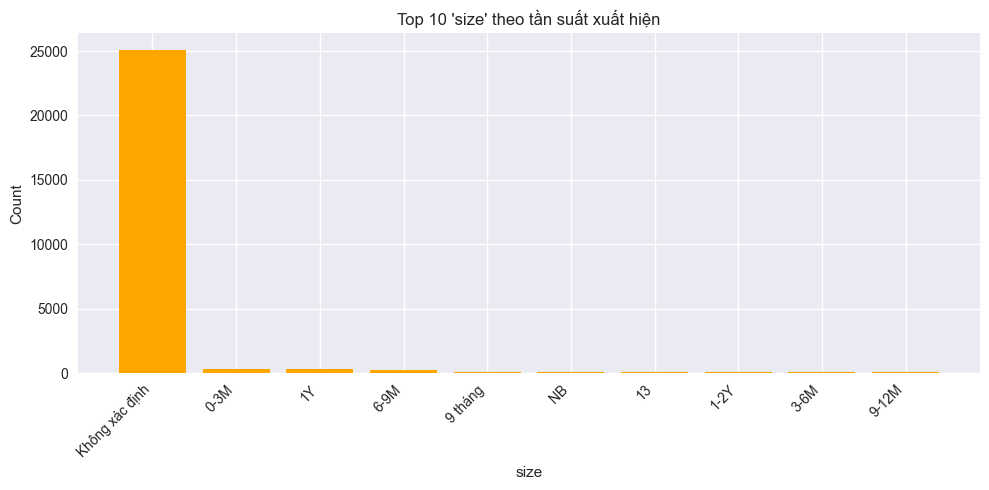


🔹 Top 10 giá trị phổ biến trong 'item_type':
              item_type   len    percent
0        Không xác định  9820  35.928582
1            Bộ quần áo  3926  14.364115
2                    Áo  1904   6.966193
3              Bodysuit  1456   5.327089
4                  Quần   990   3.622128
5           Giày tập đi   764   2.795258
6              Đầm, váy   708   2.590370
7                   Nón   385   1.408605
8        Sữa bột cho bé   351   1.284209
9  Bánh, kẹo dinh dưỡng   350   1.280550


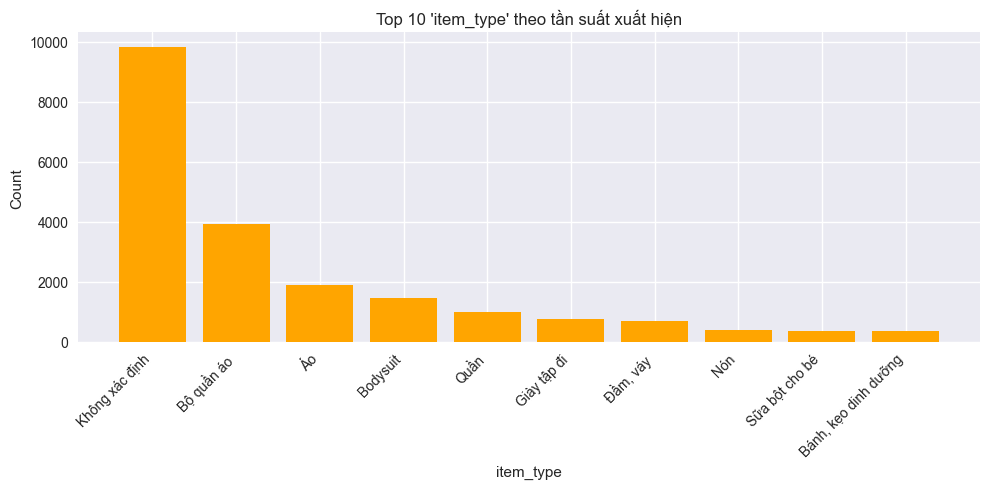


🔹 Top 10 giá trị phổ biến trong 'age_group':
        age_group    len    percent
0  Không xác định  15812  57.851603
1           Từ 3Y    944   3.453827
2          9M-12M    844   3.087956
3           6M-9M    672   2.458657
4           Từ 1Y    609   2.228157
5           Từ 2Y    577   2.111079
6           3M-6M    545   1.994000
7           Từ 6M    508   1.858627
8           0-12M    431   1.576906
9           Từ 0M    430   1.573247


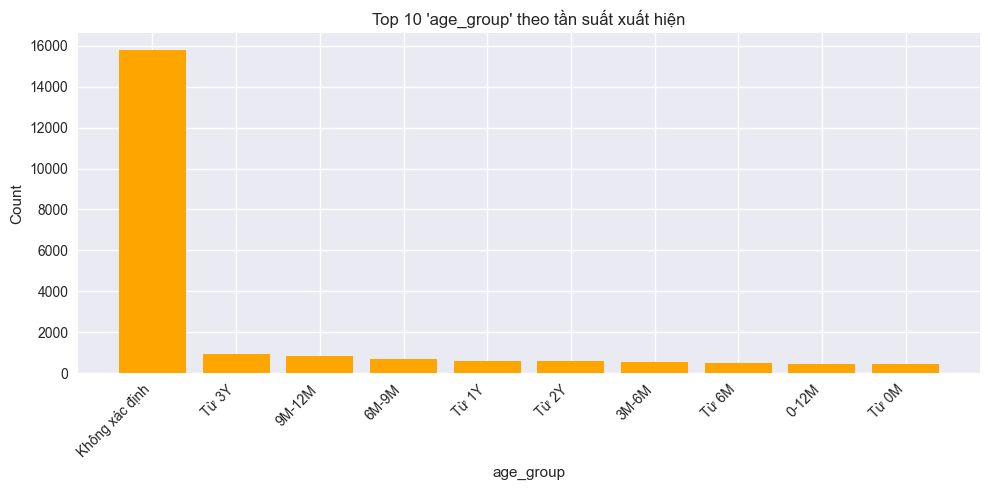


🔹 Top 10 giá trị phổ biến trong 'image_url':
        image_url    len  percent
0  Không xác định  27332    100.0


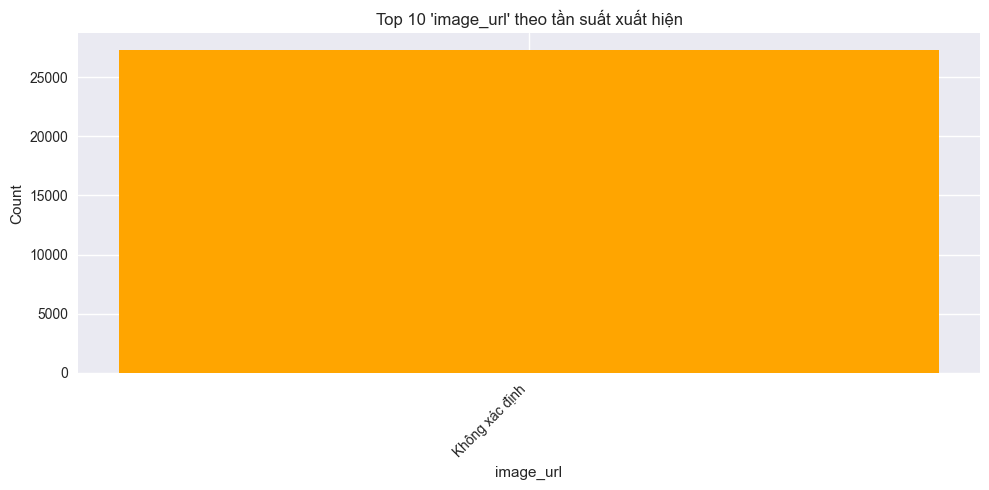


🔹 Top 10 giá trị phổ biến trong 'category_l2':
                  category_l2   len    percent
0              Cơ cấu hàng cũ  9105  33.312601
1          Thời trang bé trai  2179   7.972340
2           Thời trang bé gái  1887   6.903995
3           Modal kháng khuẩn  1711   6.260061
4                         1Y+  1565   5.725889
5  Quần áo & Phụ kiện sơ sinh  1539   5.630762
6                  Sách & VPP   736   2.692814
7                        0-1Y   654   2.392800
8                 Giày tập đi   555   2.030587
9          Bình sữa, phụ kiện   517   1.891556


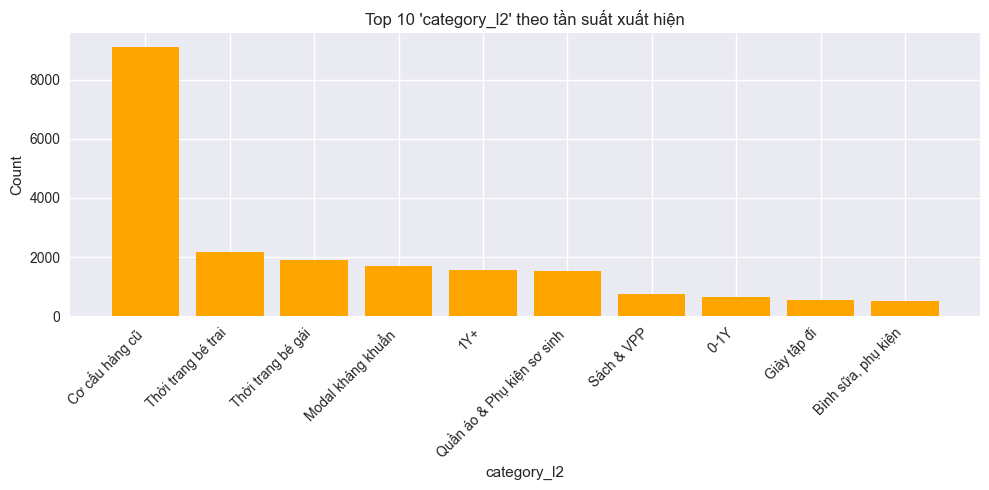


🔹 Top 10 giá trị phổ biến trong 'category_l3':
                      category_l3   len    percent
0   Thời trang bé trai, bé gái cũ  5164  18.893605
1  Quần, áo & phụ kiện sơ sinh cũ  1763   6.450315
2                      Bộ bé trai  1643   6.011269
3                        Bộ Modal  1200   4.390458
4                    Giày dép tồn  1092   3.995317
5                       Bộ bé gái   938   3.431875
6                            Sách   610   2.231816
7                              Áo   597   2.184253
8                  Bodysuit Modal   511   1.869603
9                      Đầm bé gái   497   1.818381


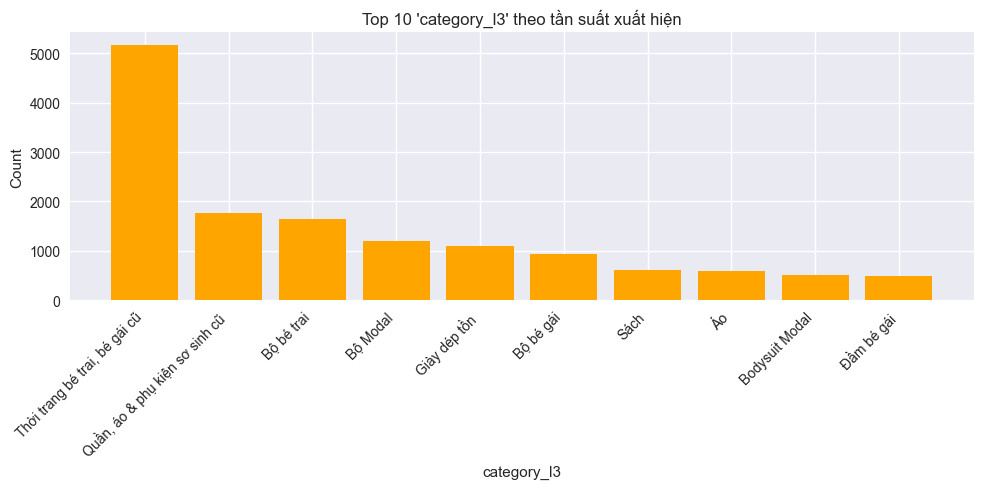


🔹 Top 10 giá trị phổ biến trong 'category':
                category   len   percent
0       Bộ bé trai Animo  1018  3.724572
1      Bộ quần áo bé gái   741  2.711108
2            Bộ Modal lẻ   740  2.707449
3              Áo bé gái   731  2.674521
4               Bodysuit   718  2.626957
5             Áo sơ sinh   713  2.608664
6  Bộ bé trai Animo Easy   625  2.286697
7           Quần sơ sinh   618  2.261086
8             Áo bé trai   611  2.235475
9       Áo sơ sinh Animo   559  2.045222


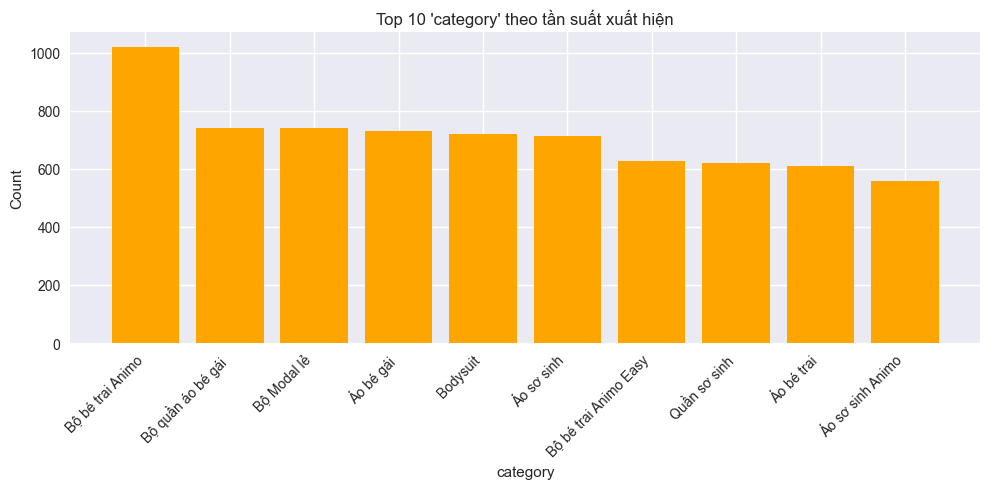

In [44]:
analyze_categorical(item_df, "brand")
analyze_categorical(item_df, "category_l1")
analyze_categorical(item_df, "manufacturer")
analyze_categorical(item_df, "origin")
analyze_categorical(item_df, "gender_target")
analyze_categorical(item_df, "sale_status")
analyze_categorical(item_df, "material")
analyze_categorical(item_df, "color")
analyze_categorical(item_df, "size")
analyze_categorical(item_df, "item_type")
analyze_categorical(item_df, "age_group")
analyze_categorical(item_df, "image_url")
analyze_categorical(item_df, "category_l2")
analyze_categorical(item_df, "category_l3")
analyze_categorical(item_df, "category")

In [53]:
if isinstance(item_df, pl.LazyFrame):
    df = item_df.collect()
else:
    df = item_df

# Tên cột cần thống kê (ví dụ)
col_name = "sync_error_message"
top_n = 10

# Đếm tần suất & tính phần trăm
freq = (
    df
    .group_by(col_name)
    .len()
    .with_columns(
        (pl.col("len") / pl.col("len").sum() * 100).alias("percent")
    )
    .sort("len", descending=True)
    .limit(top_n)
)


print(f"\n🔹 Top {top_n} giá trị phổ biến trong '{col_name}':")
print(freq)


🔹 Top 10 giá trị phổ biến trong 'sync_error_message':
shape: (1, 3)
┌────────────────────┬───────┬─────────┐
│ sync_error_message ┆ len   ┆ percent │
│ ---                ┆ ---   ┆ ---     │
│ str                ┆ u32   ┆ f64     │
╞════════════════════╪═══════╪═════════╡
│ null               ┆ 27332 ┆ 100.0   │
└────────────────────┴───────┴─────────┘


## Biến thời gian

In [38]:
def analyze_datetime(df, col_name):
    # Nếu là LazyFrame → collect
    if isinstance(df, pl.LazyFrame):
        df = df.collect()
    
    print(f"\n Phân tích biến thời gian: {col_name}")
    series = df[col_name]

    # Chuẩn hóa kiểu dữ liệu
    if series.dtype == pl.Int64:
        # Chuyển từ timestamp (giây) → datetime
        df = df.with_columns(
            pl.from_epoch(pl.col(col_name)).alias(col_name)
        )
    elif series.dtype != pl.Datetime:
        # Nếu là string hoặc kiểu khác, thử convert sang datetime
        df = df.with_columns(
            pl.col(col_name).str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S", strict=False).alias(col_name)
        )

    # Lấy lại cột đã chuẩn hóa
    series = df[col_name]

    # Thống kê cơ bản
    min_date = series.min()
    max_date = series.max()
    null_count = series.null_count()

    print(f"   • Kiểu dữ liệu sau chuẩn hóa: {series.dtype}")
    print(f"   • Khoảng thời gian: {min_date} → {max_date}")
    print(f"   • Số giá trị thiếu: {null_count:,}")

    # Vẽ histogram phân bố theo thời gian
    series_pd = series.to_pandas()
    plt.figure(figsize=(10, 4))
    plt.hist(series_pd.dropna(), bins=30, color='skyblue', edgecolor='black')
    plt.title(f"Phân bố thời gian của '{col_name}'")
    plt.xlabel("Thời gian")
    plt.ylabel("Tần suất")
    plt.tight_layout()
    plt.show()

    return df  # Trả về DataFrame đã chuẩn hóa (để tái sử dụng)


 Phân tích biến thời gian: creation_timestamp
   • Kiểu dữ liệu sau chuẩn hóa: Datetime(time_unit='us', time_zone=None)
   • Khoảng thời gian: 2011-02-21 11:54:02 → 2025-08-22 17:35:14
   • Số giá trị thiếu: 0


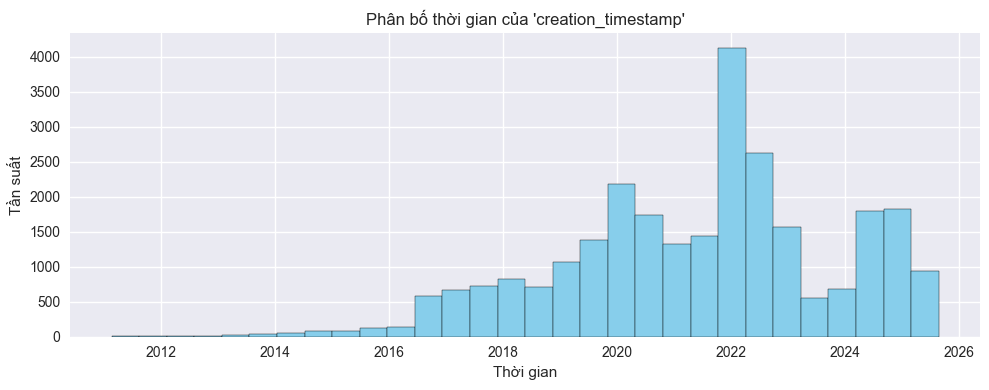


 Phân tích biến thời gian: created_date
   • Kiểu dữ liệu sau chuẩn hóa: Datetime(time_unit='us', time_zone=None)
   • Khoảng thời gian: 2011-02-21 11:54:02.047000 → 2025-08-22 17:35:14.377000
   • Số giá trị thiếu: 0


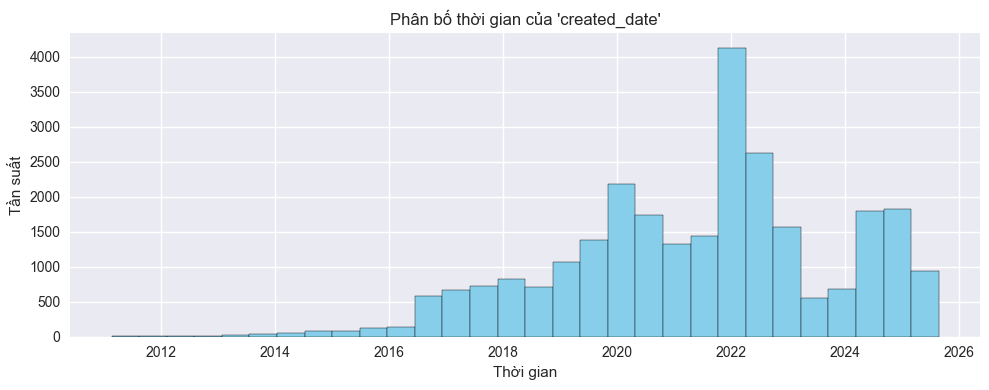


 Phân tích biến thời gian: updated_date
   • Kiểu dữ liệu sau chuẩn hóa: Datetime(time_unit='us', time_zone=None)
   • Khoảng thời gian: 2023-12-26 17:21:11.663000 → 2025-10-01 08:05:42.990000
   • Số giá trị thiếu: 0


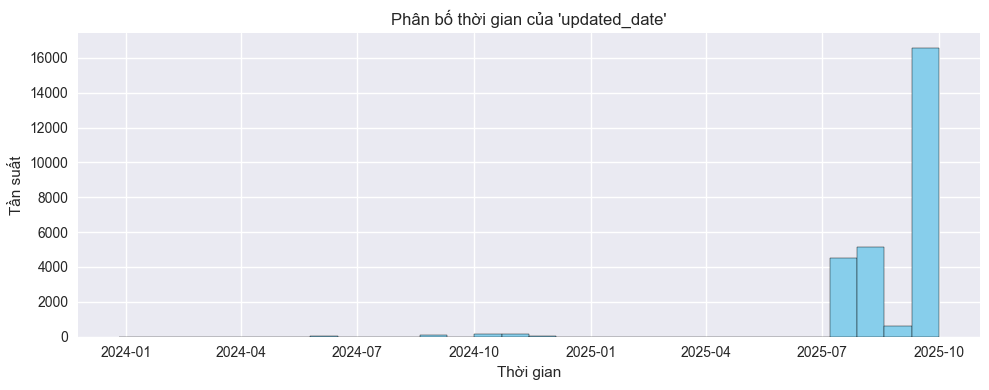


 Phân tích biến thời gian: last_sync_date
   • Kiểu dữ liệu sau chuẩn hóa: Datetime(time_unit='us', time_zone=None)
   • Khoảng thời gian: 2025-07-18 17:59:29.898256 → 2025-07-21 10:59:04.045058
   • Số giá trị thiếu: 786


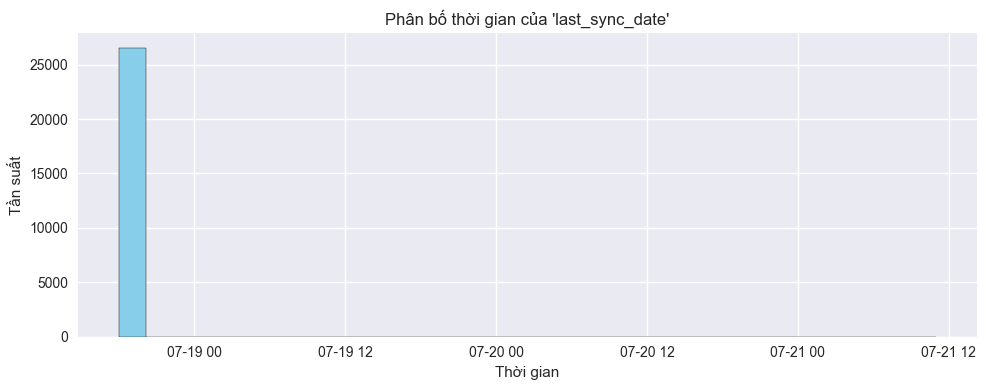

In [39]:
item_df = analyze_datetime(item_df, "creation_timestamp")
item_df = analyze_datetime(item_df, "created_date")
item_df = analyze_datetime(item_df, "updated_date")
item_df = analyze_datetime(item_df, "last_sync_date")